# Complex Sinkhorn continuation

This notebook illustrates the local holomorphic continuation of Sinkhorn dual potentials.  We fix a real temperature $\epsilon_0>0$ and solve the complex scaling equations for
\[
    \epsilon = \epsilon_0 + i\eta,
\]
where $\eta$ stays in a small interval around zero.  The first panel shows the centered real perturbation $\Re(f_\epsilon-f_{\epsilon_0})$, which makes the second-order real variation visible; the second panel shows $\Im f_\epsilon$.  In both cases the real-temperature branch $\eta=0$ is emphasized in black.

The computation uses a damped log-domain continuation in $\eta$.  This is intentionally local: complex Sinkhorn scalings are not positive couplings, and the usual contraction arguments for real $\epsilon>0$ no longer apply.


In [1]:
from pathlib import Path
import os
import shutil
import sys

os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/mpl-ot4ml")

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

# Make the notebook robust both from the repository root and from notebooks-figures/.
for candidate in [Path.cwd() / "notebooks-figures", Path.cwd(), Path.cwd().parent / "notebooks-figures"]:
    if (candidate / "figure_style.py").exists():
        sys.path.insert(0, str(candidate.resolve()))
        break

from figure_style import BLUE, GRAY, RED, VIOLET, ROOT, box_axes, figure_dir, save_pdf, setup_matplotlib

setup_matplotlib()

NAME = "sinkhorn-complex-epsilon-continuation"
OUT = figure_dir(NAME)
ARXIV_OUT = ROOT / "arxiv" / "figures"
THUMB_OUT = ROOT / "notebooks-figures" / "thumbnails"
ARXIV_OUT.mkdir(parents=True, exist_ok=True)
THUMB_OUT.mkdir(parents=True, exist_ok=True)

## One-dimensional data

The two marginals are smooth one-dimensional mixtures sampled on a common grid.  A tiny positive floor avoids artificial zero tails in the finite histogram; this keeps the local complex continuation well conditioned while leaving the visible densities unchanged.

In [2]:
def gaussian_pdf(x, mean, sigma):
    return np.exp(-0.5 * ((x - mean) / sigma) ** 2) / (np.sqrt(2 * np.pi) * sigma)

n = 130
x = np.linspace(-2.8, 2.8, n)
C = (x[:, None] - x[None, :]) ** 2

alpha_density = 0.58 * gaussian_pdf(x, -1.15, 0.40) + 0.42 * gaussian_pdf(x, 0.70, 0.32)
beta_density = 0.42 * gaussian_pdf(x, -0.55, 0.38) + 0.58 * gaussian_pdf(x, 1.25, 0.46)

floor = 1e-6
alpha_density = alpha_density + floor * alpha_density.max()
beta_density = beta_density + floor * beta_density.max()
a = alpha_density / alpha_density.sum()
b = beta_density / beta_density.sum()

## Complex log-domain continuation

For a fixed branch of the logarithm, the absorbed dual variables solve
\[
    P_{ij}=\exp\left(\frac{f_i+g_j-C_{ij}}{\epsilon}\right),\qquad
    P\mathbf 1=a,\quad P^\top\mathbf 1=b,
\]
with the gauge $\sum_i a_i f_i=0$.  Starting from the real solution at $\eta=0$, we continue the solution toward positive and negative imaginary parts.

In [3]:
def complex_logsumexp(Z, axis):
    # Stable log-sum-exp for complex arrays, using the real part for centering.
    # We keep the principal logarithm while solving; the plotted branch is unwrapped later.
    m = np.max(Z.real, axis=axis, keepdims=True)
    return np.squeeze(m, axis=axis) + np.log(np.sum(np.exp(Z - m), axis=axis))


def normalize_gauge(f, g):
    shift = np.dot(a, f)
    return f - shift, g + shift


def marginal_error(f, g, eps):
    P = np.exp((f[:, None] + g[None, :] - C) / eps)
    return max(
        float(np.max(np.abs(P.sum(axis=1) - a))),
        float(np.max(np.abs(P.sum(axis=0) - b))),
        float(abs(np.dot(a, f))),
    )


def real_log_sinkhorn(eps0, max_iter=5000, tol=1e-13):
    f = np.zeros_like(a)
    g = np.zeros_like(b)
    err = np.inf
    for it in range(max_iter):
        f = eps0 * (np.log(a) - complex_logsumexp((g[None, :] - C) / eps0, axis=1)).real
        g = eps0 * (np.log(b) - complex_logsumexp((f[:, None] - C) / eps0, axis=0)).real
        f, g = normalize_gauge(f, g)
        if it % 100 == 0:
            err = marginal_error(f, g, eps0)
            if err < tol:
                break
    return f.astype(complex), g.astype(complex), err


def complex_log_sinkhorn(eps, f0, g0, damping=0.45, max_iter=4000, tol=1e-9):
    f = f0.astype(complex).copy()
    g = g0.astype(complex).copy()
    err = np.inf
    for it in range(max_iter):
        f_new = eps * (np.log(a) - complex_logsumexp((g[None, :] - C) / eps, axis=1))
        f = (1 - damping) * f + damping * f_new
        g_new = eps * (np.log(b) - complex_logsumexp((f[:, None] - C) / eps, axis=0))
        g = (1 - damping) * g + damping * g_new
        f, g = normalize_gauge(f, g)
        if it % 100 == 0:
            err = marginal_error(f, g, eps)
            if err < tol:
                break
            if not np.isfinite(err):
                raise RuntimeError(f"Complex Sinkhorn became unstable for epsilon={eps}.")
    return f, g, err


epsilon0 = 0.55
eta_max = 0.35
etas = np.linspace(-eta_max, eta_max, 25)

f0, g0, real_error = real_log_sinkhorn(epsilon0)
solutions = {0.0: (f0, g0, real_error)}

# Continue away from the real axis in both directions, using the previous eta as warm start.
for sign in (1.0, -1.0):
    f_prev, g_prev = f0, g0
    for eta in sign * np.linspace(0, eta_max, (len(etas) + 1) // 2)[1:]:
        f_prev, g_prev, err = complex_log_sinkhorn(epsilon0 + 1j * eta, f_prev, g_prev)
        solutions[float(eta)] = (f_prev, g_prev, err)

max_error = max(err for _, _, err in solutions.values())
print(f"maximum marginal/gauge error: {max_error:.2e}")

maximum marginal/gauge error: 2.44e-10


## Plotting

The color encodes $\eta$: blue for negative imaginary parts, violet near zero, and red for positive imaginary parts.  The first panel uses the centered real perturbation because the real part of the potential itself changes only at second order in $\eta$ and would otherwise be visually hidden by the $\eta=0$ curve.


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


...

'modified' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


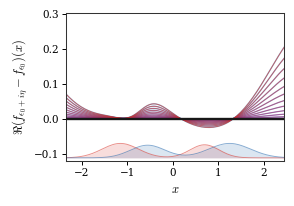

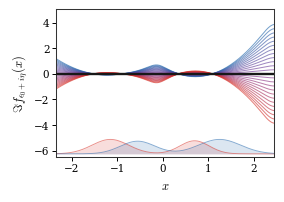

In [4]:
eta_cmap = LinearSegmentedColormap.from_list("eta", [BLUE, VIOLET, RED])
eta_values = np.array(sorted(solutions.keys()))
zero_index = int(np.argmin(np.abs(eta_values)))
source_potentials = np.array([solutions[float(eta)][0] for eta in eta_values])


def unwrap_display_branch(f, eps):
    # The complex potential is defined modulo 2*pi*i*epsilon on each grid point.
    # For plotting, choose the continuous branch of log(u)=f/epsilon along the line.
    log_u = f / eps
    log_u = log_u.real + 1j * np.unwrap(log_u.imag)
    f_unwrapped = eps * log_u
    return f_unwrapped - np.dot(a, f_unwrapped)


plot_source_potentials = np.array(
    [unwrap_display_branch(solutions[float(eta)][0], epsilon0 + 1j * eta) for eta in eta_values]
)
real_variation = plot_source_potentials.real - plot_source_potentials[zero_index].real[None, :]
imaginary_part = plot_source_potentials.imag


def eta_color(eta):
    t = (eta + eta_max) / (2 * eta_max)
    return eta_cmap(np.clip(t, 0, 1))


def density_silhouette(ax, ymin, ymax):
    span = ymax - ymin
    base = ymin - 0.22 * span
    height = 0.13 * span
    ax.fill_between(x, base, base + height * alpha_density / alpha_density.max(), color=RED, alpha=0.16, lw=0)
    ax.fill_between(x, base, base + height * beta_density / beta_density.max(), color=BLUE, alpha=0.16, lw=0)
    ax.plot(x, base + height * alpha_density / alpha_density.max(), color=RED, lw=0.65, alpha=0.55)
    ax.plot(x, base + height * beta_density / beta_density.max(), color=BLUE, lw=0.65, alpha=0.55)
    ax.set_ylim(base - 0.03 * span, ymax + 0.08 * span)


def plot_potential_part(ax, values, ylabel, paired_overlap=False):
    ymin, ymax = float(values.min()), float(values.max())
    if ymax - ymin < 1e-10:
        ymin -= 1.0
        ymax += 1.0
    pad = 0.06 * (ymax - ymin)
    ymin -= pad
    ymax += pad
    density_silhouette(ax, ymin, ymax)

    if paired_overlap:
        # Re(f_epsilon-f_epsilon0) is almost even in eta.  Draw negative
        # branches slightly wider so that the two signs remain perceptible.
        order = [i for i, eta in enumerate(eta_values) if eta < -1e-14]
        order += [i for i, eta in enumerate(eta_values) if eta > 1e-14]
        for i in order:
            eta = eta_values[i]
            lw = 0.95 if eta < 0 else 0.58
            alpha = 0.50 if eta < 0 else 0.70
            ax.plot(x, values[i], color=eta_color(eta), lw=lw, alpha=alpha, solid_capstyle="round")
    else:
        for eta, curve in zip(eta_values, values):
            if abs(eta) < 1e-14:
                continue
            ax.plot(x, curve, color=eta_color(eta), lw=0.72, alpha=0.62, solid_capstyle="round")

    zero_curve = values[zero_index]
    ax.plot(x, zero_curve, color="#181818", lw=1.7, solid_capstyle="round", zorder=5)
    ax.axhline(0, color="#b5b5b5", lw=0.45, zorder=0)
    ax.set_xlim(-2.35, 2.45)
    ax.set_xlabel(r"$x$")
    ax.set_ylabel(ylabel)
    ax.tick_params(labelsize=7.5, pad=1.5)
    box_axes(ax)


def make_panel(part, ylabel, pdf_name):
    values = real_variation if part == "real" else imaginary_part
    fig, ax = plt.subplots(figsize=(2.82, 1.92))
    plot_potential_part(ax, values, ylabel, paired_overlap=(part == "real"))
    save_pdf(fig, OUT / pdf_name)
    shutil.copyfile(OUT / pdf_name, ARXIV_OUT / f"{NAME}--{pdf_name}")
    return fig, ax

fig_re, ax_re = make_panel("real", r"$\Re(f_{\epsilon_0+i\eta}-f_{\epsilon_0})(x)$", "real-potential.pdf")
fig_im, ax_im = make_panel("imag", r"$\Im f_{\epsilon_0+i\eta}(x)$", "imag-potential.pdf")
plt.show()

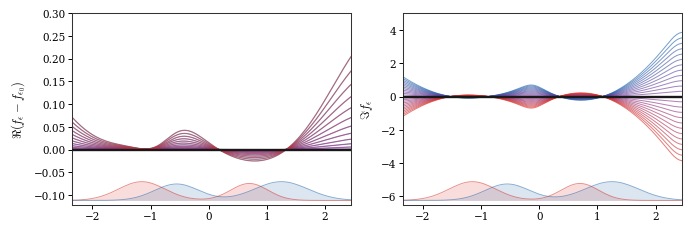

/Users/gpeyre/Dropbox/github/ot4ml/notebooks-figures/thumbnails/sinkhorn-complex-epsilon-continuation.png


In [5]:
# Compact thumbnail for the notebook gallery and MyST page.
fig, axes = plt.subplots(1, 2, figsize=(6.8, 2.2), constrained_layout=True)
plot_potential_part(axes[0], real_variation, r"$\Re(f_\epsilon-f_{\epsilon_0})$", paired_overlap=True)
plot_potential_part(axes[1], imaginary_part, r"$\Im f_\epsilon$")
for ax in axes:
    ax.set_xlabel("")
thumb = THUMB_OUT / f"{NAME}.png"
fig.savefig(thumb, dpi=220, bbox_inches="tight", pad_inches=0.04)
plt.show()
print(thumb)